In [1]:
import pandas as pd

df = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")

df.shape
df.head()

,id,age,gender,race,education,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,...,smoking_ever,physical_activity_freq,sleep_hours,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type,marital_status,household_size,is_employed
0,130378.0,43.0,Male,Non-Hispanic Asian,College graduate or above,5.00,86.9,179.5,27.0,135.0,...,Unknown,45.0,9.5,No,Insured,Yes,Private only,Married / living with partner,4.0,Yes
1,130379.0,66.0,Male,Non-Hispanic White,College graduate or above,5.00,101.8,174.2,33.5,121.0,...,Unknown,45.0,9.0,No,Insured,Unknown,Both,Married / living with partner,2.0,Yes
2,130380.0,44.0,Female,Other Hispanic,High school/GED,1.41,69.4,152.9,29.7,111.0,...,Unknown,30.0,8.0,Yes,Insured,Unknown,Public only,Married / living with partner,7.0,Yes
3,130384.0,43.0,Male,Mexican American,9-11th grade,0.63,87.5,176.0,28.3,120.0,...,Unknown,60.0,7.5,No,Not insured,Unknown,Uninsured,Never married,2.0,Yes
4,130385.0,65.0,Female,Non-Hispanic White,High school/GED,5.00,72.7,159.2,28.7,127.0,...,Unknown,60.0,8.0,No,Insured,No,Public only,Married / living with partner,2.0,No


In [2]:
numeric_features = [
    "age",
    "income_poverty_ratio",
    "bmi",
    "sbp",
    "dbp",
    "a1c",
    "sleep_hours",
    "physical_activity_freq",
    "household_size"
]
categorical_features = [
    "gender",
    "race",
    "education",
    "marital_status",
    "is_employed",
    "smoking_current"
]
clustering_features = numeric_features + categorical_features

df_cluster = df[clustering_features].copy()
df_cluster.head()


,age,income_poverty_ratio,bmi,sbp,dbp,a1c,sleep_hours,physical_activity_freq,household_size,gender,race,education,marital_status,is_employed,smoking_current
0,43.0,5.00,27.0,135.0,98.0,5.6,9.5,45.0,4.0,Male,Non-Hispanic Asian,College graduate or above,Married / living with partner,Yes,Yes
1,66.0,5.00,33.5,121.0,84.0,5.6,9.0,45.0,2.0,Male,Non-Hispanic White,College graduate or above,Married / living with partner,Yes,Yes
2,44.0,1.41,29.7,111.0,79.0,6.2,8.0,30.0,7.0,Female,Other Hispanic,High school/GED,Married / living with partner,Yes,No
3,43.0,0.63,28.3,120.0,77.0,5.4,7.5,60.0,2.0,Male,Mexican American,9-11th grade,Never married,Yes,No
4,65.0,5.00,28.7,127.0,74.0,5.7,8.0,60.0,2.0,Female,Non-Hispanic White,High school/GED,Married / living with partner,No,No


In [3]:
from sklearn.preprocessing import StandardScaler

# 1. 先复制一份
df_processed = df_cluster.copy()

# 2. 转换类别变量类型
for col in categorical_features:
    df_processed[col] = df_processed[col].astype(str)

# 3. 数值标准化
scaler = StandardScaler()
df_processed[numeric_features] = scaler.fit_transform(df_processed[numeric_features])

df_processed.head()


,age,income_poverty_ratio,bmi,sbp,dbp,a1c,sleep_hours,physical_activity_freq,household_size,gender,race,education,marital_status,is_employed,smoking_current
0,-0.492907,1.407966,-0.355640,0.792494,2.324926,-0.098965,1.092785,-0.182267,0.927300,Male,Non-Hispanic Asian,College graduate or above,Married / living with partner,Yes,Yes
1,0.746857,1.407966,0.640394,-0.057776,0.926581,-0.098965,0.781830,-0.182267,-0.419023,Male,Non-Hispanic White,College graduate or above,Married / living with partner,Yes,Yes
2,-0.439004,-0.945190,0.058097,-0.665112,0.427172,0.529187,0.159921,-0.553481,2.946786,Female,Other Hispanic,High school/GED,Married / living with partner,Yes,No
3,-0.492907,-1.456461,-0.156433,-0.118510,0.227408,-0.308349,-0.151034,0.188947,-0.419023,Male,Mexican American,9-11th grade,Never married,Yes,No
4,0.692954,1.407966,-0.095139,0.306625,-0.072238,0.005727,0.159921,0.188947,-0.419023,Female,Non-Hispanic White,High school/GED,Married / living with partner,No,No


In [4]:
from kmodes.kprototypes import KPrototypes
import numpy as np

# 将 dataframe 转成 numpy，用于 K-Prototypes
data_matrix = df_processed.to_numpy()

# 记录不同 K 的 cost
cost = []
K_range = [3, 4, 5]

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=5, verbose=1, random_state=42)
    clusters = kproto.fit_predict(data_matrix, categorical=[df_processed.columns.get_loc(c) for c in categorical_features])
    cost.append(kproto.cost_)

cost

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 1857, ncost: 69285.51995946385
Run: 1, iteration: 2/100, moves: 651, ncost: 69029.86849410189
Run: 1, iteration: 3/100, moves: 381, ncost: 68871.9893873087
Run: 1, iteration: 4/100, moves: 251, ncost: 68814.00964417704
Run: 1, iteration: 5/100, moves: 187, ncost: 68782.80303157424
Run: 1, iteration: 6/100, moves: 139, ncost: 68763.66040332253
Run: 1, iteration: 7/100, moves: 86, ncost: 68755.08648606097
Run: 1, iteration: 8/100, moves: 81, ncost: 68749.44669198287
Run: 1, iteration: 9/100, moves: 30, ncost: 68748.41748593551
Run: 1, iteration: 10/100, moves: 11, ncost: 68748.25032651941
Run: 1, iteration: 11/100, moves: 5, ncost: 68748.11506899128
Run: 1, iteration: 12/100, moves: 12, ncost: 68747.94646104838
Run: 1, iteration: 13/100, moves: 3, ncost: 68747.9347893579
Run: 1, iteration: 14/100, move

[68589.58281873727, 64388.97024019632, 60320.713937270375]

In [5]:
# 1. 最终选择的 K
best_k = 4

# 2. 重新跑一次 K-Prototypes（可以关闭 verbose 或设成 0）
kproto_final = KPrototypes(
    n_clusters=best_k,
    init='Cao',
    n_init=5,
    verbose=0,
    random_state=42
)

clusters = kproto_final.fit_predict(
    data_matrix,
    categorical=[df_processed.columns.get_loc(c) for c in categorical_features]
)

# 3. 把簇标签加回原始 dataframe
df_processed['cluster'] = clusters

# 数值型特征的均值
df_processed.groupby('cluster')[numeric_features].mean()

# 类别特征的分布
for col in categorical_features:
    print(col)
    print(df_processed.groupby('cluster')[col].value_counts(normalize=True))
    print("------")


gender
cluster  gender
0        Female    0.587699
         Male      0.412301
1        Female    0.635770
         Male      0.364230
2        Female    0.542609
         Male      0.457391
3        Male      0.553386
         Female    0.446614
Name: proportion, dtype: float64
------
race
cluster  race              
0        Non-Hispanic White    0.615490
         Non-Hispanic Black    0.128474
         Other Hispanic        0.088383
         Other Race / Multi    0.075626
         Mexican American      0.054214
         Non-Hispanic Asian    0.037813
1        Non-Hispanic White    0.426893
         Other Hispanic        0.155788
         Non-Hispanic Black    0.150131
         Mexican American      0.132724
         Other Race / Multi    0.076153
         Non-Hispanic Asian    0.058312
2        Non-Hispanic White    0.529565
         Non-Hispanic Black    0.197391
         Other Hispanic        0.089565
         Other Race / Multi    0.070435
         Mexican American      0.064348


In [6]:
df_processed.columns

Index(['age', 'income_poverty_ratio', 'bmi', 'sbp', 'dbp', 'a1c',
       'sleep_hours', 'physical_activity_freq', 'household_size', 'gender',
       'race', 'education', 'marital_status', 'is_employed', 'smoking_current',
       'cluster'],
      dtype='object')

In [7]:
df_raw = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")
df_raw.columns

Index(['id', 'age', 'gender', 'race', 'education', 'income_poverty_ratio',
       'weight_kg', 'height_cm', 'bmi', 'sbp', 'dbp', 'a1c', 'glucose',
       'smoking_current', 'smoking_ever', 'physical_activity_freq',
       'sleep_hours', 'diabetes_self_report', 'has_health_insurance',
       'doctor_visit_12m', 'insurance_type', 'marital_status',
       'household_size', 'is_employed'],
      dtype='object')

In [8]:
# 1. 确认两张表行数一致（保险起见）
print(len(df_raw), len(df_processed))

# 2. 把聚类结果加回原始完整数据
df_raw['cluster'] = df_processed['cluster'].values


8153 8153


In [9]:
# 每个聚类画像中，不同保险类型所占的比例
pd.crosstab(
    df_raw['cluster'],
    df_raw['insurance_type'],
    normalize='index'   # 每个 cluster 内做比例
)


insurance_type,Both,Private only,Public only,Uninsured,Unknown
cluster,,,,,
0,0.277449,0.082005,0.580410,0.052847,0.007289
1,0.024369,0.376849,0.401218,0.164056,0.033507
2,0.184348,0.303478,0.409565,0.095652,0.006957
3,0.161355,0.607570,0.181275,0.041434,0.008367


In [10]:
# 如果 diabetes_self_report 是 Yes / No
pd.crosstab(
    df_raw['cluster'],
    df_raw['diabetes_self_report'],
    normalize='index'
).round(3)


diabetes_self_report,Borderline,Don't know,No,Unknown,Yes
cluster,,,,,
0,0.048,0.0,0.673,0.0,0.278
1,0.017,0.0,0.952,0.0,0.031
2,0.052,0.0,0.761,0.0,0.187
3,0.027,0.0,0.902,0.0,0.071


**Cluster-based segmentation reveals four distinct population groups with meaningful differences in insurance coverage and health risks.**

**Cluster 0 (High-risk, publicly insured group)**:
Dominated by public insurance (58%) and dual coverage (28%), this group has the highest diabetes prevalence (27.8%). Characteristics align with vulnerable populations relying heavily on public health programs.

**Cluster 1 (Young, low-risk working adults)**:
Mostly privately insured (37.7%) with the lowest diabetes rate (3.1%). Higher employment rates suggest this cluster represents healthier working-age adults.

**Cluster 2 (Mixed-coverage, intermediate-risk group)**:
A blend of private, public, and dual coverage users, with a moderate diabetes rate (18.7%). This cluster appears to be a transitional demographic with mixed socioeconomic backgrounds.

**Cluster 3 (High-income, privately insured healthy group)**:
The highest private insurance rate (60.6%) and low diabetes prevalence (7.1%) make this a relatively advantaged, health-stable group with higher education and income.

In [11]:
# 1. 自定义每个 cluster 的标签
cluster_labels = {
    0: "High-risk publicly insured group",
    1: "Young healthy workers",
    2: "Mixed-coverage middle group",
    3: "High-income privately insured group"
}

# 2. 映射到 dataframe
df_raw["cluster_label"] = df_raw["cluster"].map(cluster_labels)

# 3. 看看效果
df_raw[["cluster", "cluster_label"]].head()


,cluster,cluster_label
0,2,Mixed-coverage middle group
1,3,High-income privately insured group
2,1,Young healthy workers
3,1,Young healthy workers
4,3,High-income privately insured group


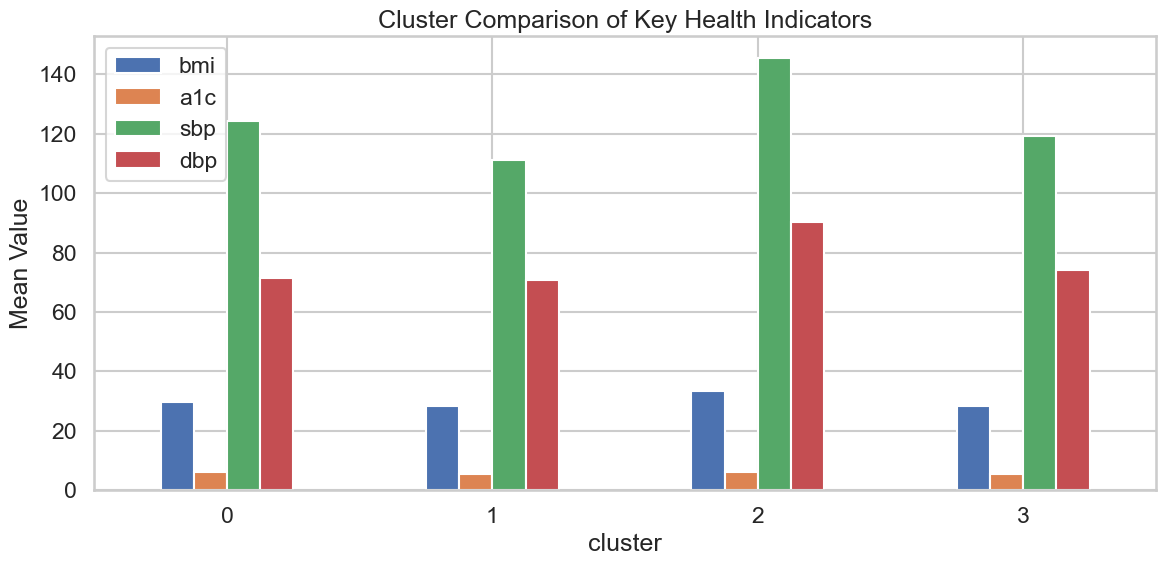

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 建议：统一设置风格（可选）
sns.set_theme(style="whitegrid", context="talk")

# ========= 0. 设置保存路径 =========
save_dir = "/Users/wmhjoy/Data_Mining_Project/reports/figures/"
os.makedirs(save_dir, exist_ok=True)  # 如果不存在就创建

# 4个健康指标聚类后的平均值
health_vars = ["bmi", "a1c", "sbp", "dbp"]

cluster_health_means = df_raw.groupby("cluster")[health_vars].mean()

cluster_health_means.plot(kind="bar", figsize=(12,6))
plt.title("Cluster Comparison of Key Health Indicators")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "cluster_health_barplot.png"),
            dpi=300, bbox_inches="tight")
plt.show()


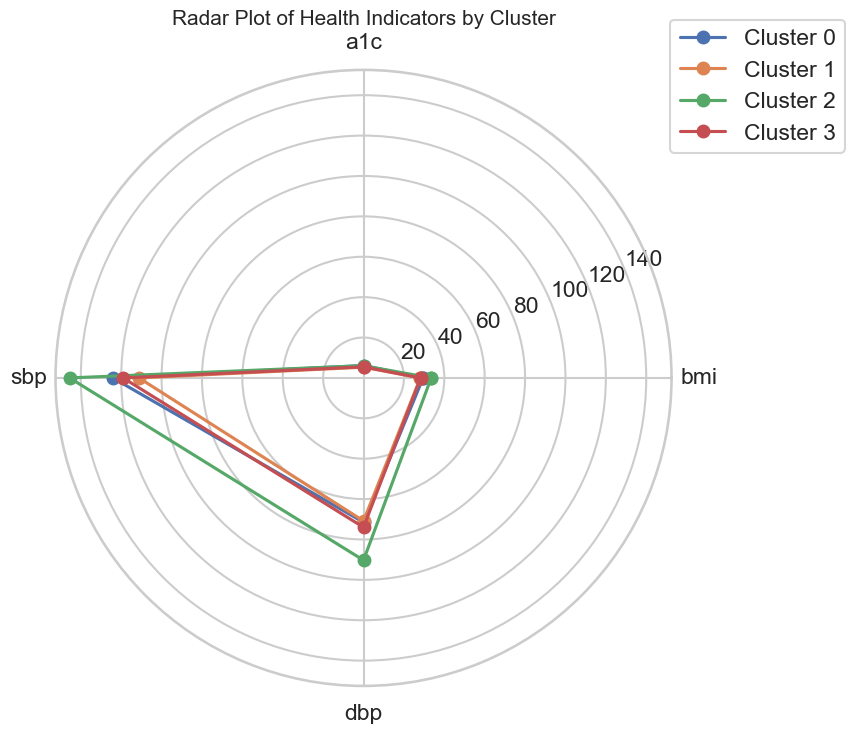

In [13]:
# 需要展示的变量
vars = ["bmi", "a1c", "sbp", "dbp"]
stats = df_raw.groupby("cluster")[vars].mean()

# 雷达图角度
angles = np.linspace(0, 2 * np.pi, len(vars), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))

for i in range(4):
    values = stats.iloc[i].tolist()
    values += values[:1]

    plt.polar(angles, values, marker='o', label=f"Cluster {i}")

plt.xticks(angles[:-1], vars)
plt.title("Radar Plot of Health Indicators by Cluster", size=15)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.savefig(os.path.join(save_dir, "cluster_health_radar.png"),
            dpi=300, bbox_inches="tight")
plt.show()


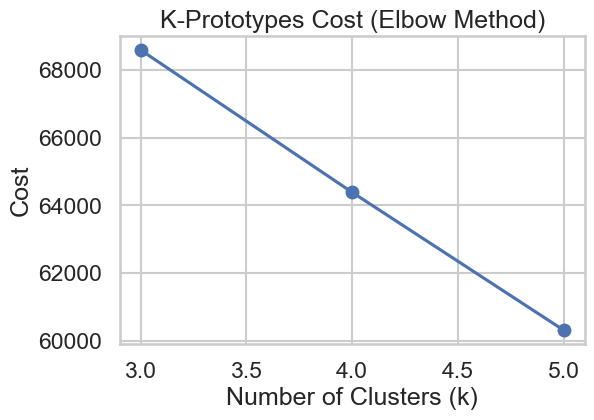

In [14]:
plt.figure(figsize=(6,4))
plt.plot(K_range, cost, marker='o')
plt.title("K-Prototypes Cost (Elbow Method)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Cost")
plt.grid(True)
plt.show()


In [15]:
pip install gower


Note: you may need to restart the kernel to use updated packages.


In [17]:
import gower
from sklearn.metrics import silhouette_score

# 计算 Gower 距离矩阵
gower_dist = gower.gower_matrix(df_processed.drop(columns=['cluster']))

# silhouette score（需要距离矩阵）
sil_score = silhouette_score(gower_dist, df_processed['cluster'], metric='precomputed')

print("Silhouette Score:", sil_score)


Silhouette Score: 0.07581129


In [18]:
import numpy as np

# 1. 类内方差（数值变量）
intra_var = df_processed.groupby("cluster")[numeric_features].var()
print("Intra-cluster variance:")
print(intra_var)

# 2. 类之间 prototype 距离
prototypes = kproto_final.cluster_centroids_
print("Cluster centroids:")
print(prototypes)


Intra-cluster variance:
              age  income_poverty_ratio       bmi       sbp       dbp  \
cluster                                                                 
0        0.284324              0.518949  0.775030  0.638181  0.566697   
1        0.412879              0.604955  0.956925  0.339497  0.532422   
2        0.555122              0.897179  1.851623  1.224422  0.885082   
3        0.675945              0.306502  0.604362  0.446036  0.517522   

              a1c  sleep_hours  physical_activity_freq  household_size  
cluster                                                                 
0        1.787408     1.229932                0.683022        0.473780  
1        0.140991     0.987274                1.003920        1.107765  
2        1.923177     1.152177                1.425144        0.818958  
3        0.226937     0.632124                1.070228        0.445827  
Cluster centroids:
[['0.8684392266700858' '-0.5250796415568624' '0.02890921926423949'
  '0.13280820